# Scene Classification using VGG

Steps:
1. Importing (or installing) Tensorflow, Keras and other packages on your system
2. Defining your tensorflow CNN model architecture
3. Loading your data from disk
4. Creating your training and testing splits
5. Data Preprocessing (Augumentation)
6. Compiling your tensorflow CNN model
7. Training your model on your training data
8. Saving The train model
9. Generate Plots for accuracy and validation loss
10. Making predictions using your trained tensorflow model

##### Select GPU Runtime, Install Tensorflow and restart the runtime

In [1]:
# !pip install  -q tensorflow
!pip install  -q  gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.5 MB/s eta 0:00:00


#### connect Drive folder to colab and set working dir

In [2]:
# conect to google drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
# set present working directory in google colab
import os
os.chdir("/content/drive/MyDrive/Project")

### Step 1: Importing all the packages

In [4]:
# import the necessary packages     https://justpaste.it/d2luq
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import random
import cv2
import os
import gradio as gr

import warnings
from tqdm import tqdm_notebook as tqdm
import itertools
import tensorflow as tf

print("Tensorlfow Version: ", tf.__version__)
warnings.filterwarnings("ignore")
SEED = 42   # set random seed

Tensorlfow Version:  2.18.0


In [ ]:
# # extract the rar data file using patool lib (run only once)
# !pip install -q patool
# import patoolib
# patoolib.extract_archive("vgg_dataset.rar")
# patoolib.extract_archive("test_examples.rar")

In [10]:
# class label
CLASSES = ["buildings", "forest", "sea"]

DATASET = "vgg_dataset"  # this folde must contain three subfolder with images

# set the batch size when fine-tuning
BATCH_SIZE = 64

EPOCHS = 15
INIT_LR = 1e-3

trainPath = r"vgg_dataset/train"
testPath =  r"vgg_dataset/test"

In [11]:
from imutils import paths
# determine the total number of image paths in training, validation,
# and testing directories
totalTrain = len(list(paths.list_images(trainPath)))
totalTest = len(list(paths.list_images(testPath)))
print(totalTrain)
print(totalTest)

1217
559


In [12]:
# initialize the training data augmentation object
trainAug = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest")

# initialize the validation/testing data augmentation object (which
# we'll be adding mean subtraction to)
valAug = ImageDataGenerator()

# define the ImageNet mean subtraction (in RGB order) and set the
# the mean subtraction value for each of the data augmentation
# objects
mean = np.array([123.68, 116.779, 103.939], dtype="float32")
trainAug.mean = mean
valAug.mean = mean

In [13]:
# initialize the training generator
trainGen = trainAug.flow_from_directory(
    trainPath,
    class_mode="categorical",
    target_size=(224, 224),
    color_mode="rgb",
    shuffle=True,
    batch_size=BATCH_SIZE)


# initialize the testing generator
testGen = valAug.flow_from_directory(
    testPath,
    class_mode="categorical",
    target_size=(224, 224),
    color_mode="rgb",
    shuffle=False,
    batch_size=BATCH_SIZE)

Found 1217 images belonging to 3 classes.
Found 559 images belonging to 3 classes.


In [ ]:
# Vgg16 model with Top included (check the summary)
baseModel = VGG16(weights="imagenet", include_top=True,
                  input_tensor=Input(shape=(224, 224, 3)))

baseModel.summary()


In [ ]:
# Vgg16 model with Top excluded (check the summary and understand the difference)
baseModel = VGG16(weights="imagenet", include_top=False,
                  input_tensor=Input(shape=(224, 224, 3)))

baseModel.summary()

### Define VGG model

In [14]:
# load the VGG16 network, ensuring the head FC layer sets are left
# off
baseModel = VGG16(weights="imagenet", include_top=False,
                  input_tensor=Input(shape=(224, 224, 3)))

# construct the head of the model that will be placed on top of the
# the base model
headModel = baseModel.output
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(400, activation="relu")(headModel)
headModel = Dense(400, activation="relu")(headModel)
# headModel = Dropout(0.5)(headModel)
headModel = Dense(len(CLASSES), activation="softmax")(headModel)

# place the head FC model on top of the base model (this will become
# the actual model we will train)
vgg_model = Model(inputs=baseModel.input, outputs=headModel)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
vgg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 400)                 │      10,035,600 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 24,911,891 (95.03 MB)

 Trainable params: 24,911,891 (95.03 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
    layer.trainable = False

In [17]:
# compile our model (this needs to be done after our setting our
# layers to being non-trainable
print("[INFO] compiling model...")
opt = SGD(learning_rate=1e-4, momentum=0.9)
vgg_model.compile(loss="categorical_crossentropy", optimizer=opt,
              metrics=["accuracy"])

[INFO] compiling model...


In [18]:
# train the head of the network for a few epochs (all other layers
# are frozen) -- this will allow the new FC layers to start to become
# initialized with actual "learned" values versus pure random
EP = 10

print("[INFO] training head...")
H = vgg_model.fit(
    x=trainGen,
    steps_per_epoch=totalTrain // BATCH_SIZE,
    validation_data=testGen,
    validation_steps=totalTest // BATCH_SIZE,
    epochs=EP)


[INFO] training head...
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 501s 26s/step - accuracy: 0.5460 - loss: 4.1952 - val_accuracy: 0.9668 - val_loss: 0.2258
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9375 - loss: 0.2399 - val_accuracy: 0.9648 - val_loss: 0.2669
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9301 - loss: 0.5506 - val_accuracy: 0.9805 - val_loss: 0.1438
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - accuracy: 0.9219 - loss: 0.8528 - val_accuracy: 0.9805 - val_loss: 0.1431
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9375 - loss: 0.5851 - val_accuracy: 0.9785 - val_loss: 0.1917
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.9531 - loss: 0.6876 - val_accuracy: 0.9785 - val_loss: 0.1858
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9529 - loss: 0.3181 - val_accuracy: 0.9805 - val_loss: 0.1134
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 1.0000 - loss: 0.0095 - 

In [ ]:
print("[INFO] serializing network...")
vgg_model.save("vgg_model_{}_epochs.model".format(EP), save_format="h5")

In [19]:
vgg_model.save("vgg_model_updated_10_epochs.h5")

In [20]:
# reset the testing generator and evaluate the network after
# fine-tuning just the network head
from tensorflow.keras.models import load_model
vgg_model2 = load_model("vgg_model_updated_10_epochs.h5")

print("[INFO] evaluating after fine-tuning network head...")
testGen.reset()
predIdxs = vgg_model2.predict(x=testGen,
    steps=(totalTest // BATCH_SIZE) + 1)
predIdxs = np.argmax(predIdxs, axis=1)

[INFO] evaluating after fine-tuning network head...
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


In [21]:
def plot_acc(H, N, plotPath=None):
    # construct a plot that plots and saves the training history
    plt.style.use("ggplot")
    plt.figure()
    plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
    plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
    plt.title("Training Accuracy")
    plt.xlabel("Epoch #")
    plt.ylabel("Accuracy")
    plt.legend(loc="lower left")
    plt.savefig("acc_output.png")

def plot_loss(H, N, plotPath=None):
    # construct a plot that plots and saves the training history
    plt.style.use("ggplot")
    plt.figure()
    plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
    plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")

    plt.title("Training Loss")
    plt.xlabel("Epoch #")
    plt.ylabel("Loss")
    plt.legend(loc="lower left")
    plt.savefig("loss_output.png")

In [22]:
print(classification_report(testGen.classes, predIdxs,
    target_names=testGen.class_indices.keys()))

              precision    recall  f1-score   support

   buildings       0.97      0.98      0.98       190
      forest       0.98      0.99      0.99       182
         sea       0.98      0.96      0.97       187

    accuracy                           0.98       559
   macro avg       0.98      0.98      0.98       559
weighted avg       0.98      0.98      0.98       559



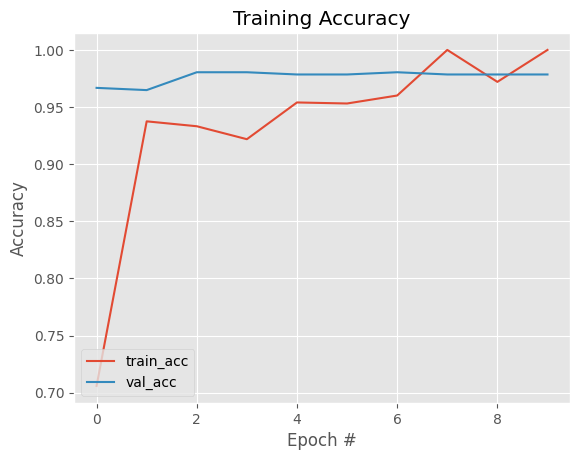

In [23]:
# plot training and val accuracy
plot_acc(H, EP)

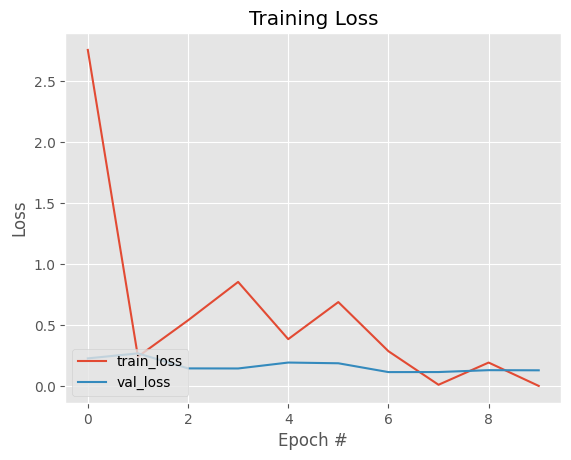

In [24]:
# plot training and val loss
plot_loss(H, EP)

## Inference on Unseen Data

In [25]:
import imutils
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
import numpy as np
import argparse
import imutils
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [26]:
def display_img(img):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img)

In [ ]:
# import the necessary packages
from tensorflow.keras.models import load_model
import pickle
import cv2

# # load the model
print("[INFO] loading network and...")
model = load_model("vgg_model_updated_10_epochs.h5")

# grab the image paths and randomly shuffle themt
testImagePaths = sorted(list(paths.list_images('test_examples')))   # data folder with 2 categorical folders


# progress bar
with tqdm(total=len(testImagePaths)) as pbar:

    for imagePath in testImagePaths:

        image = cv2.imread(imagePath)
        output = image.copy()
        output = imutils.resize(output, width=400)

        # our model was trained on RGB ordered images but OpenCV represents
        # images in BGR order, so swap the channels, and then resize to
        # 224x224 (the input dimensions for VGG16)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))

        # convert the image to a floating point data type and perform mean
        # subtraction
        image = image.astype("float32")
        mean = np.array([123.68, 116.779, 103.939][::-1], dtype="float32")
        image -= mean


        # pass the image through the network to obtain our predictions
        preds = model.predict(np.expand_dims(image, axis=0))[0]
        i = np.argmax(preds)
        label = CLASSES[i]

        # draw the prediction on the output image
        text = "{}: {:.2f}%".format(label, preds[i] * 100)
        cv2.putText(output, text, (3, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
            (0, 255, 0), 2)

         # convert img to rgb format and display in notebook
        img = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
        display_img(img)

        pbar.update(1)


### Deployment

In [ ]:
# build gradio app
# !pip install gradio

In [32]:
import gradio as gr
model = load_model("vgg_model_updated_10_epochs.h5")

def predict_image(image):


    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))

    # convert the image to a floating point data type and perform mean
    # subtraction
    image = image.astype("float32")
    mean = np.array([123.68, 116.779, 103.939][::-1], dtype="float32")
    image -= mean

    # pass the image through the network to obtain our predictions
    preds = model.predict(np.expand_dims(image, axis=0))[0]

    result = dict()
    result["Buildings"] = round(float(list(preds)[0]), 3)
    result["Forest"] = round(float(list(preds)[1]), 3)
    result["Sea"] = round(float(list(preds)[2]), 3)

    print(result)

    return result


In [ ]:
im = gr.Image()
label = gr.Label(num_top_classes=3)
gr.Interface(fn = predict_image, inputs=im, outputs=label, title="VGG DEMO").launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://fc46672d29a61343b1.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 962ms/step
{'Buildings': 0.0, 'Forest': 0.998, 'Sea': 0.002}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
{'Buildings': 1.0, 'Forest': 0.0, 'Sea': 0.0}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
{'Buildings': 0.983, 'Forest': 0.0, 'Sea': 0.017}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
{'Buildings': 1.0, 'Forest': 0.0, 'Sea': 0.0}
